#### Case study: The North Atlantic Oscillation

This case study follows the example from the [Climate Book](https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week7/naoeof.html) by Karen Smith. We have chopped off a few parts of the analysis. These are for you to write. A Notebook with the full solution will be provided next Thursday. You could directly look at the solution in the link we provided, but we'd recommend giving it a try first - it's up to you!

We will use the Empirical Orthogonal Function (EOF) method to construct the North Atlantic Oscillation (NAO) index. The index is a measure of the strenght of westerly winds in the North Atlantic, and a proxy for climate variability influencing weather in Europe and North America. It was somethat introduced by Sir Gilbert Walker in 1932, using measurements recorded at weather stations in Ponta Delgada on the Azores and Stykkisholmur in Iceland.

The index is built from surface sea-level pressure (SLP) differences in the Subtropical High and the Subpolar Low. The index reflects anomalies, or fluctuations, in the pressure gradient, which in turn affect the strenght and position of the westerly jet stream and storm tracks.

Since the NAO is most active during the winter season we will focus our analysis using multi-year data of the SLP during the months of December, January, February and March.

Download the NetCDF file here ([link](https://www.dropbox.com/s/brssg2g5m2tzn6y/ERAI_PSL_1980_2017.nc?dl=0))

In [1]:
# load packages
import numpy as np
from netCDF4 import Dataset
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
from scipy import linalg as LA
mpl.rc('font',size=14) #set default font size and weight for plots
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Data is from the ERA-Interim reanalysis data product.
# It was downloaded from http://apps.ecmwf.int/datasets/data/interim-full-moda/levtype=sfc/
# only Dec, Jan, Feb and Mar of each season are contained in this file

# open netcdf file
fname = '../data/ERAI_PSL_1980_2017.nc' 
nc    = xr.open_dataset(fname) #Dataset(fname)
slp   = nc['msl'].data # np.squeeze(nc.variables['msl'][:,:,:]) # time, lat, lon
lon   = nc['longitude'].data #nc.variables['longitude'][:]
lat   = nc['latitude'].data #nc.variables['latitude'][:]

Let's make a sanity check, we should have 4 months x 38 years = 152 time steps

In [83]:
print(slp.shape,len(lat),len(lon))

(152, 241, 480) 241 480


##### Prepare the region of study

In [3]:
# We will work with the seasonal mean, so we need to take the winter mean for each year
# To Do --> create average winter seasons (Dec-Mar). 
n_year = 38
slp_djfm = np.zeros((n_year, len(lat), len(lon)))
for i in range (n_year):
    # print(f'averaging month indexes of {i*4} to {i*4+4 - 1}')
    slp_djfm[i, :, :] = slp[i*4:i*4+4, :, :].mean(axis=0)

# Make a print to see the resulting array makes sense
slp_djfm.shape

(38, 241, 480)

In [4]:
# The downloaded file is global, but we only need the region under scope.
# To Do --> extract only latitudes 20N-90N
lat_nao = lat[ (lat >= 20) & (lat <= 90) ]

# To Do --> extract only longitudes 90W-30E
# For plotting reasons we shift the longitude slice so that it is
# monotolically increasing (if you're using xarray there's no need to do this)
lon2 = lon[ (lon >= 270) & (lon <= 360) ] - 360 # -90 to 30
lon1 = lon[ lon <= 30 ]

# the second slice is
# lon2 = lon[360:480] - 360 # 

# To Do --> the first slice


# To Do --> Now stack them 
lon_nao =  np.hstack((lon2,lon1))

In [5]:
# To Do --> to the same with the SLP array (no need to substract anything now)
idxs_lat = (lat >= 20) & (lat <= 90)
idxs_lon2 = (lon >= 270) & (lon <= 360) 
idxs_lon1 = (lon <= 30)

slp_djfm_nao1 = slp_djfm[:, idxs_lat, :][:, :, idxs_lon1].copy()
slp_djfm_nao2 = slp_djfm[:, idxs_lat, :][:, :, idxs_lon2].copy()
slp_djfm_nao = np.concatenate((slp_djfm_nao2, slp_djfm_nao1), axis=2)

We plot the arrays lon_nao,lat_nao,slp_djfm_nao

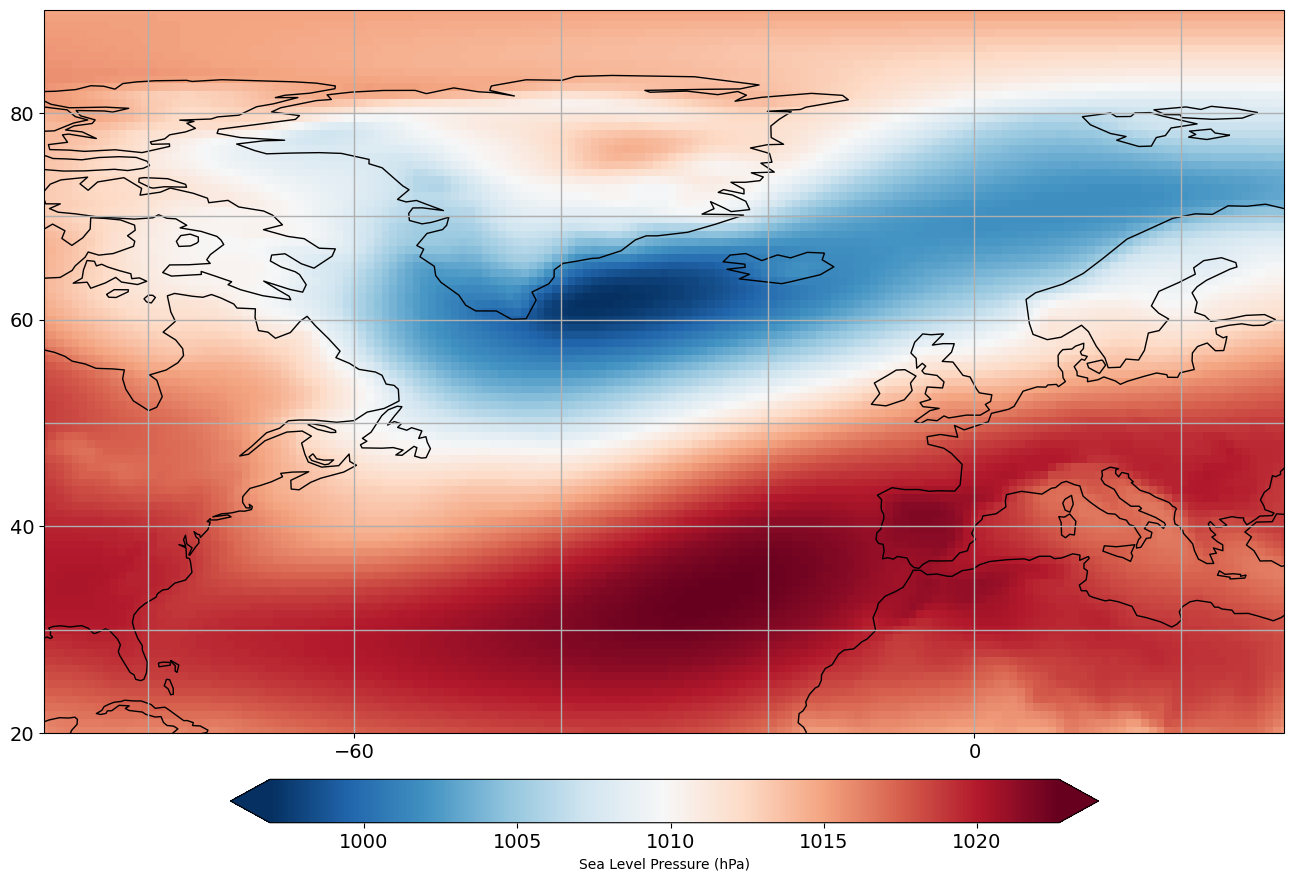

In [6]:
# set up plot
fig = plt.figure(figsize=(16,12))

# define the map projection: the projection keyword determines how the plot will look
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines()
ax.gridlines(linewidth=1)
ax.set_xticks([-60, 0, 60],crs=ccrs.PlateCarree())
ax.set_yticks([20, 40, 60, 80],crs=ccrs.PlateCarree())
# added ax.set_extent
ax.set_extent([-90,30,20,90])

# plot data
pc = ax.pcolormesh(lon_nao,lat_nao,np.mean(slp_djfm_nao,axis=0)/100.0,cmap="RdBu_r")

# add colorbar
cax,kw = mpl.colorbar.make_axes(ax,location='bottom',pad=0.05,shrink=0.7)
out=fig.colorbar(pc,cax=cax,extend='both',**kw)
out.set_label('Sea Level Pressure (hPa)',size=10)

Q: Does this make sense with the NAO premise?

We can now start the EOF analysis

#### Steps

##### Step 1: Remove the mean

The NAO index aims to describe fluctuations around a mean state, so we first need to "center" our data.

In [74]:
# To Do --> remove the time mean, i.e., calculate anomalies (subtract the mean over each time series for each grid point)
slp_djfm_anom_nao = slp_djfm_nao -  slp_djfm_nao.mean(axis=0)

##### Step 3: Weighting gridded data

Since we are working with gridded data we need to weight each grid box with its area. Since our data is on a rectangular grid in the sphere the size of the boxes decreases with latitude, so we'll weight it as $\omega = cos(\theta)$

In [75]:
# To Do --> cosine-weight
# Hint: Use the array lat_nao ; the argument must be in radians
cos_wgt = np.cos((lat_nao*np.pi/180.0)) # Deleted

# We now create a new array we we'll store the weighted data
slp_djfm_anom_cw = np.zeros((slp_djfm_anom_nao.shape[0],slp_djfm_anom_nao.shape[1],slp_djfm_anom_nao.shape[2]))

# To Do --> iterate over time and longitude to multiply the cos_wgt and slp_djfm_anom_nao vectors
for i in range (slp_djfm_anom_cw.shape[0]):
    for j in range (slp_djfm_anom_cw.shape[2]):
        slp_djfm_anom_cw[i, :, j] = cos_wgt * slp_djfm_anom_nao[i, :, j]

##### Step 4: reshape data matrix

In [76]:
# To Do --> reshape the array to have one time dimension and one spatial dimension (Nt = time, Ny = latitude, Nx = longitude)
Nt, Ny, Nx = slp_djfm_anom_cw.shape
slp_djfm_anom_cw.shape = (Nt, Ny*Nx)  

In [77]:
# Now re-structure it to have an array with dimensions [NyNx x Nt] ([p x n])
slp_djfm_anom_cw = (slp_djfm_anom_cw)

##### Step 5: Calc

We can now calculate the covariance matrix

In [78]:
# To Do --> calculate the covariance matrix
C = np.cov(slp_djfm_anom_cw)
print(C.shape)

(38, 38)


##### Step 6: Perform eigenanalysis of the covariance matrix

$$ C e_j = \lambda e_j$$

In [79]:
# eigenanalyze C
# hint: Use Numpy's linalg module. It will return two arrays, containing the
#       eigenvalues (1st array) and eigenvectors (2nd array)
eigenvalues, eigenvectors = np.linalg.eig(C)

Let's look at the first eigenvector $\rightarrow e_1$

In [89]:
# To Do --> extract the 1st eigenvector (EOF1)
EOF1 = np.dot(slp_djfm_anom_cw.T, eigenvectors[:, 0])
mag = np.linalg.norm(EOF1)
EOF1 = EOF1 / mag
print(EOF1.shape)

(15134,)


We now extract the first Principal Component, $\text{PC}_1$, by projecting our original data onto $e_1$

In [90]:
# To Do --> Transpose the EOF matrix and then project
PC1 = eigenvectors[:, 0] * mag #np.dot(EOF1, slp_djfm_anom_cw.transpose())

In [82]:
print(PC1.shape)

(38,)


In [91]:
# We now reshape the matrix into the original spatial grid
EOF1_reshaped = np.reshape(np.real(EOF1),(Ny,Nx))

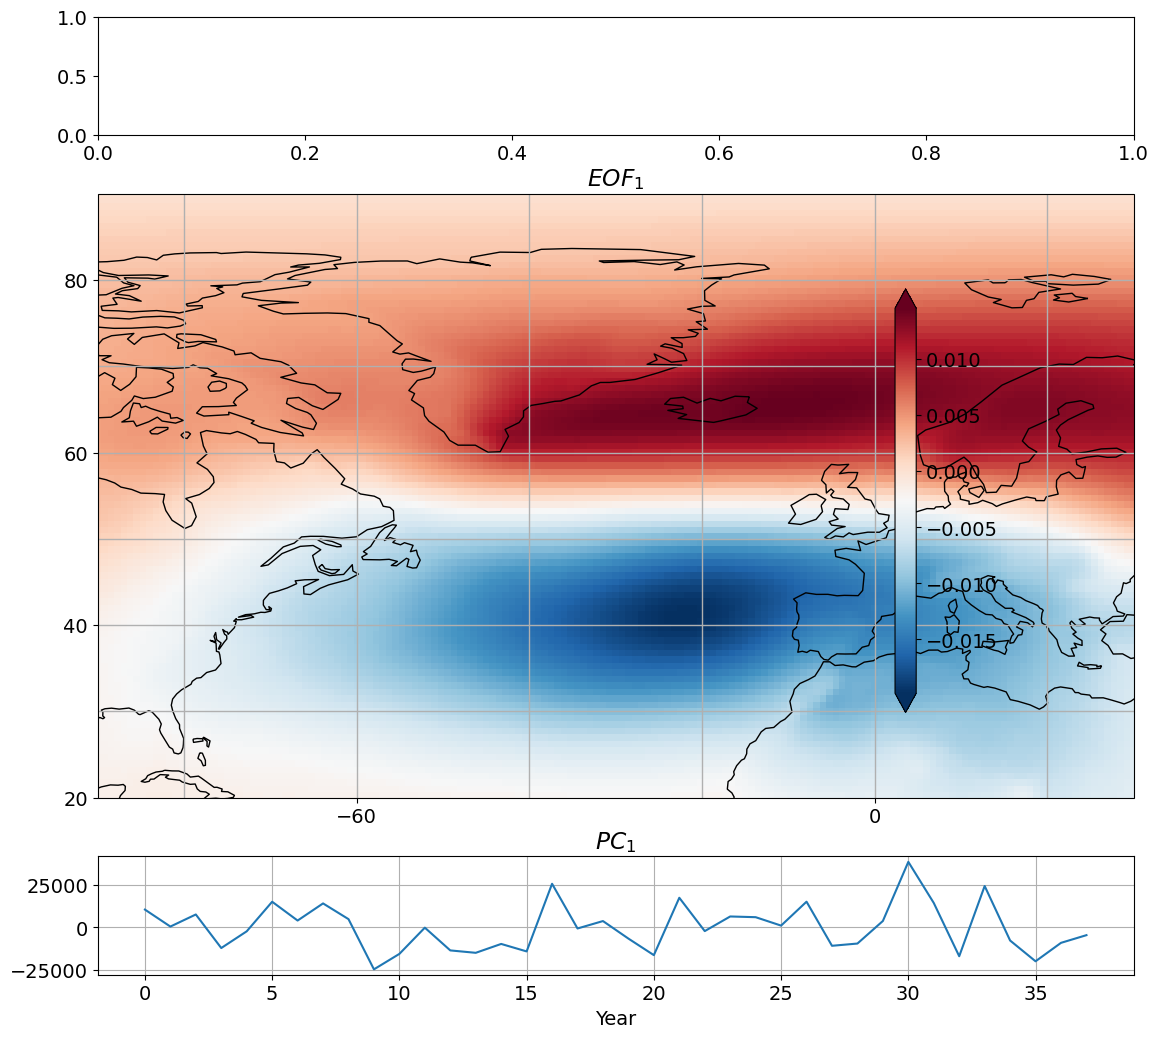

In [92]:
# look at first eof pattern and pc timeseries
fig = plt.figure(figsize=(12,10))
ax1 = fig.add_subplot(6,1,1)
ax1 = plt.axes(projection=ccrs.PlateCarree())
ax1.coastlines()
ax1.gridlines(linewidth=1)
ax1.set_xticks([-60, 0, 60],crs=ccrs.PlateCarree())
ax1.set_yticks([20, 40, 60, 80],crs=ccrs.PlateCarree())
# added ax.set_extent
ax1.set_extent([-90,30,20,90])
ax1.set_title(r'$EOF_1$')
pc = ax1.pcolormesh(lon_nao, lat_nao, EOF1_reshaped,cmap='RdBu_r')
cax,kw = mpl.colorbar.make_axes(ax1,location='right',pad=0.001,shrink=0.55)
out=fig.colorbar(pc,cax=cax,extend='both',**kw)
#plt.tight_layout()

ax2 = fig.add_subplot(6,1,6)
plt.plot(PC1)
plt.grid()
ax2.set_title(r'$PC_1$')
plt.xlabel('Year')
plt.tight_layout()

In [93]:
# Check for normalization of the first EOF
print(f'{np.real(np.dot(EOF1.transpose(), EOF1)):.5f}')

1.00000
